Loading Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip

Loading Class Labels and gene symbols to get gene ids

In [2]:
class_labels = pd.read_csv("data/class.tsv", header=None, names=["Class"])["Class"]

cols = pd.read_csv("data/columns.tsv.gz", sep="\t", comment="#")

genes = cols.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]

gene_ids=genes["ID"].astype(str)


Loading gene expression data and getting those required expressions levels for XBP1 and GATA3  

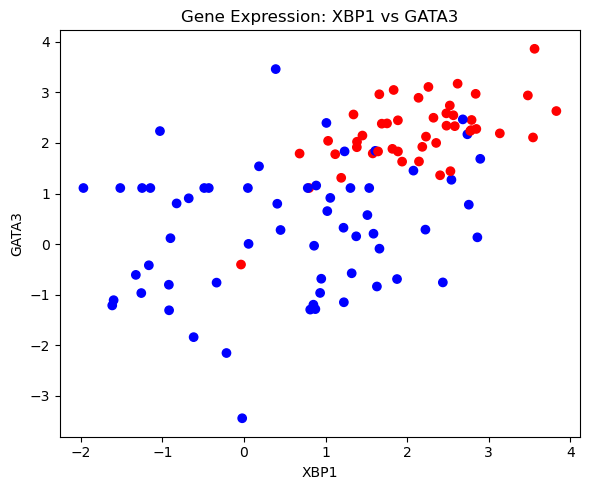

In [3]:
with gzip.open("data/filtered.tsv.gz", "rt") as f:
    gene_expressions = pd.read_csv(f, sep="\t")

gene_expressions.columns = gene_expressions.columns.str.strip()

expressions_req = gene_expressions[gene_ids]
expressions_req.columns = ["XBP1", "GATA3"]

colors = class_labels.map({1: "red", 0: "blue"})

plt.figure(figsize=(6, 5))
plt.scatter(expressions_req["XBP1"], expressions_req["GATA3"], c=colors)
plt.xlabel("XBP1")
plt.ylabel("GATA3")
plt.title("Gene Expression: XBP1 vs GATA3")
plt.tight_layout()
plt.show()

Implementing PCA from scratch 

Step 1 : Centre data

In [4]:
X = expressions_req.values
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

Step 2 : Generating Covariance Matrix

In [5]:
cov_matrix = np.cov(X_centered, rowvar=False)

Step 3 : Finding out eigenvalues and eignevectors of covariance matrix

In [6]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

Step 4 : Sorting to take the most dominant eigenvector and corresponding eigenvalue (the most significant one will capture highest variance in data)

In [7]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, sorted_idx]
eigenvalues = eigenvalues[sorted_idx]

Step 5 : Projecting the data on the principal component

In [8]:
pc1 = eigenvectors[:, 0]  # First principal component
pc1d = X_centered @ pc1   # Projection onto PC1

Plotting the final graph

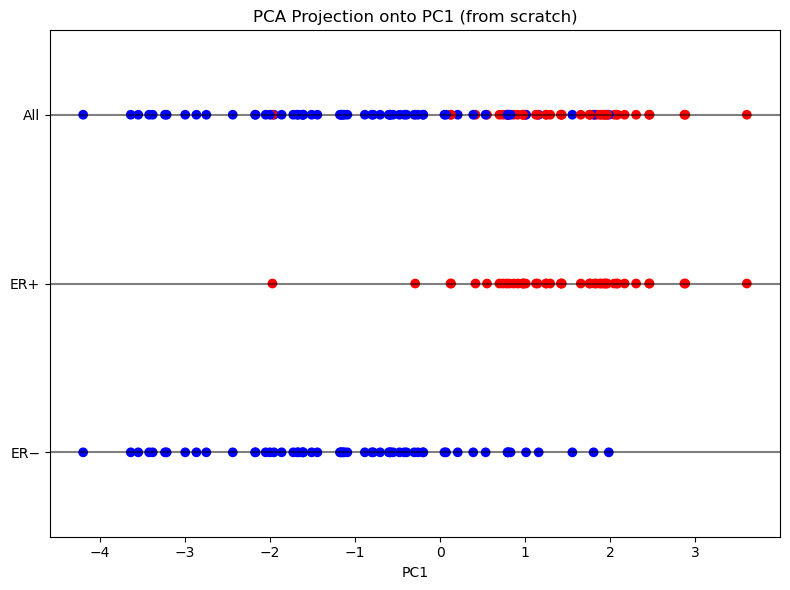

In [ ]:
# Extended values for plotting , so that we could get that "All" line in the graph
y_vals = class_labels.values
pc1d_extended = np.concatenate([pc1d, pc1d])
y_vals_extended = np.concatenate([y_vals, np.full(len(y_vals), 2)])
colors_extended = np.concatenate([colors, colors])

plt.figure(figsize=(8, 6))
plt.scatter(pc1d_extended, y_vals_extended, c=colors_extended)
plt.yticks([0, 1, 2], ["ER−", "ER+","All"])

# For horizontal lines
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.axhline(y=1, color='black', linestyle='-', alpha=0.5)  
plt.axhline(y=2, color='black', linestyle='-', alpha=0.5)

plt.ylim(-0.5, 2.5)
plt.xlabel("PC1")
plt.title("PCA Projection onto PC1 (from scratch)")
plt.tight_layout()
plt.show()